# LR Classifier on Raw Activations — Results Analysis

This notebook loads the outputs from `train_lr_classifier_streaming.py` and generates diagnostic plots across layers and granularities.

1. lr_classifier_results.json —
JSON keyed by layer number (e.g. "18", "19", …), with each layer containing metrics for each granularity.
- **Token-level metrics (evaluated on held-out shards, not cross-validated)**:
    - accuracy — fraction of correctly classified tokens on the test shards. A baseline sanity check, but can be misleading under class imbalance.
    -cauroc — area under the ROC curve, computed from clf.decision_function scores. This is the single most important metric for token-level because it's threshold-independent and insensitive to class imbalance. It tells you how well the linear classifier separates correct-reasoning tokens from incorrect-reasoning tokens in activation space.
    - f1 — harmonic mean of precision and recall at the default threshold (0). Useful because it penalizes both false positives and false negatives, but it's threshold-dependent so AUROC is more informative.
    - n_test, n_test_pos, n_test_neg — test set composition, so you can verify the class balance.
    - class_counts, class_weight_map — training class distribution and the balanced weights used during SGD, important for understanding whether the model was exposed to enough minority-class examples.
    - intercept, intercept_input_space — the learned bias term (in standardized space and projected back to input space).

- **Step-level and sample-level metrics (5-fold stratified cross-validation)**:
    - cv_roc_auc_mean / cv_roc_auc_std — the most important metric. The mean AUROC across folds tells you discriminative power; the std tells you how stable this estimate is. High std suggests the model's performance is sensitive to which data ends up in which fold, possibly due to few data points.
    - cv_accuracy_mean / cv_accuracy_std — same as above for accuracy.
    - cv_f1_mean / cv_f1_std — same for F1.
    - cv_precision_mean/std, cv_recall_mean/std — also stored, giving you the precision-recall trade-off.
    - Per-fold arrays (e.g. cv_roc_auc_folds, cv_roc_auc_train_folds) — the raw fold-by-fold values, critical for diagnosing variance and overfitting. If train-fold AUROC is much higher than test-fold AUROC, the model is overfitting.
    - n_samples, n_positive, n_negative — dataset size at this granularity.
    - n_iter / max_iter — number of LBFGS iterations the solver actually used vs the cap (2000). If n_iter == max_iter, the solver didn't converge and results may be unreliable.
    - cv_fit_time_mean/std, cv_score_time_mean/std — wall-clock timing.
    . scaler_mean_norm, scaler_var_mean — summary statistics of the StandardScaler, useful for sanity-checking that activations are in a reasonable range.

Weight vs reasoning direction comparisons (weight_vs_reasoning_vectors): cosine similarity between the learned LR weight vector (projected back to input space by dividing by scaler scales) and each pre-computed reasoning direction vector stored in the vectors file. This answers: "does the linear classifier find the same direction in activation space as the contrastive reasoning vector?" High cosine similarity (close to ±1) means the LR classifier independently rediscovered the same direction, providing strong validation. Low similarity means the supervised classifier found a different discriminative axis.

Cross-weight similarities (cross_weight_similarities): cosine similarities between weight vectors across granularities within the same layer (e.g. token_vs_step, token_vs_sample, step_vs_sample) and across layers within the same granularity. High cross-granularity similarity means all three levels of aggregation agree on the same discriminative direction — a strong consistency signal. High cross-layer similarity within a granularity means the separating hyperplane is stable across layers.

- Token-level: all reported metrics (accuracy, AUROC, F1) come from evaluating the SGD-trained model on the held-out test shards. There is no cross-validation — it's a single train/test split by shard.
- Step-level and sample-level: all reported metrics (cv_*_mean, cv_*_std, cv_*_folds) come exclusively from the cross_validate call, meaning they reflect test-fold performance averaged over the 5 stratified folds. The pipeline.fit(X, y) that follows on all data is only used to extract the weight vector and intercept for downstream analysis (cosine similarity with reasoning directions, weight sparsity plots, etc.) — it never contributes to any reported performance metric.

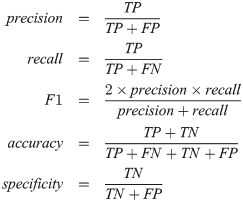

## 1 — Load all outputs

  [skip] lr_classifier_all_datasets_auroc.png: no lr_classifier_results.json
Found 3 dataset(s): ['math_shepherd', 'prm800k', 'processbench']

Saved → /home/ines/Reasoning-activations/results/lr_classifier_all_datasets_auroc.png


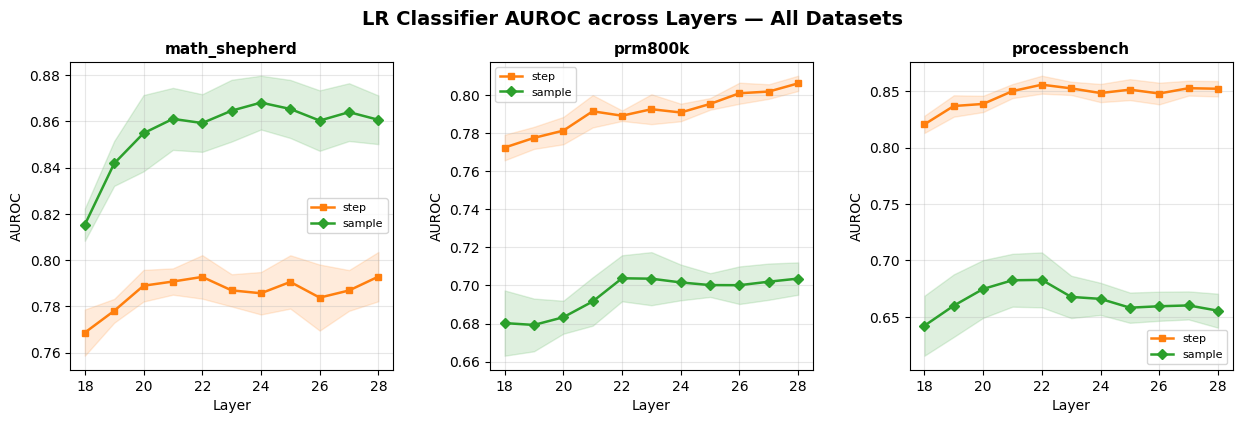

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Config ──────────────────────────────────────────────────────────────────
BASE_DIR = Path("/home/ines/Reasoning-activations/results")
PLOT_PATH = BASE_DIR / "lr_classifier_all_datasets_auroc.png"

metric_map = {
    "step":   {"auroc": "cv_roc_auc_mean"},
    "sample": {"auroc": "cv_roc_auc_mean"},
}
std_map = {
    "step":   {"auroc": "cv_roc_auc_std"},
    "sample": {"auroc": "cv_roc_auc_std"},
}

colors  = {"step": "#ff7f0e", "sample": "#2ca02c"}
markers = {"step": "s",       "sample": "D"}

GRANULARITIES = ["step", "sample"]

# ── Discover datasets ────────────────────────────────────────────────────────
classifier_dirs = sorted(BASE_DIR.glob("lr_classifier_*"))
if not classifier_dirs:
    raise FileNotFoundError(f"No lr_classifier_* directories found under {BASE_DIR}")

datasets = []
for d in classifier_dirs:
    json_path = d / "lr_classifier_results.json"
    if not json_path.exists():
        print(f"  [skip] {d.name}: no lr_classifier_results.json")
        continue
    with open(json_path) as f:
        results = json.load(f)
    dataset_name = d.name[len("lr_classifier_"):]
    datasets.append((dataset_name, results))

if not datasets:
    raise RuntimeError("No usable lr_classifier_* directories found.")

print(f"Found {len(datasets)} dataset(s): {[n for n, _ in datasets]}")

# ── Build figure: one subplot per dataset ───────────────────────────────────
n = len(datasets)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
fig.subplots_adjust(hspace=0.45, wspace=0.3)

for idx, (dataset_name, results) in enumerate(datasets):
    ax = axes[idx // ncols][idx % ncols]

    layer_keys = sorted([k for k in results if k.isdigit()], key=int)
    layers_int = [int(l) for l in layer_keys]
    available  = [g for g in GRANULARITIES if g in results.get(layer_keys[0], {})]

    for gran in available:
        vals = np.array([results[lk].get(gran, {}).get(metric_map[gran]["auroc"], np.nan)
                         for lk in layer_keys], dtype=float)
        stds = np.array([results[lk].get(gran, {}).get(std_map[gran]["auroc"], 0) or 0
                         for lk in layer_keys], dtype=float)

        ax.plot(layers_int, vals, marker=markers[gran], label=gran,
                color=colors[gran], linewidth=1.8, markersize=5)
        if stds.any():
            ax.fill_between(layers_int, vals - stds, vals + stds,
                            alpha=0.15, color=colors[gran])

    ax.set_title(dataset_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Layer", fontsize=10)
    ax.set_ylabel("AUROC", fontsize=10)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide any unused subplots
for idx in range(len(datasets), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("LR Classifier AUROC across Layers — All Datasets",
             fontsize=14, fontweight="bold", y=1.01)

fig.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
print(f"\nSaved → {PLOT_PATH}")
plt.show()